In [10]:
!pip install sentence-transformers

In [11]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

In [12]:
sentences = [
    "The batsman scored a century in the match",
    "The bowler took a wicket with a yorker",
    "The team won the cricket match by 5 runs",
    "The captain set an aggressive field",

    "Add spices and cook the curry slowly",
    "Boil the pasta until it is tender",
    "The chef prepared a delicious meal",

    "Use strong passwords to protect your accounts",
    "Hackers can exploit system vulnerabilities",
    "Install antivirus software to stay secure"
]

In [13]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
similarity_matrix = cosine_similarity(embeddings)
print(similarity_matrix)

[[ 0.9999999   0.5154662   0.5786685   0.23948291  0.14094703 -0.01510107
   0.13094799 -0.03894892  0.09368742 -0.00903653]
 [ 0.5154662   1.0000002   0.49281484  0.23842603  0.15728828  0.12182253
   0.2014848  -0.03378269  0.05114756 -0.09586972]
 [ 0.5786685   0.49281484  1.0000001   0.17692256  0.12795268  0.00466722
   0.09456982 -0.01251565  0.0639845   0.00488587]
 [ 0.23948291  0.23842603  0.17692256  1.0000002   0.01587259  0.03771295
   0.06678727  0.02487537  0.06016922 -0.05187304]
 [ 0.14094703  0.15728828  0.12795268  0.01587259  0.9999998   0.20005232
   0.43945533  0.0554919   0.10812192  0.09248798]
 [-0.01510107  0.12182253  0.00466722  0.03771295  0.20005232  1.0000001
   0.25551903  0.01224195  0.11430074  0.00308131]
 [ 0.13094799  0.2014848   0.09456982  0.06678727  0.43945533  0.25551903
   0.9999999  -0.03073503  0.13804172  0.03052794]
 [-0.03894892 -0.03378269 -0.01251565  0.02487537  0.0554919   0.01224195
  -0.03073503  1.          0.35751247  0.24097064]
 

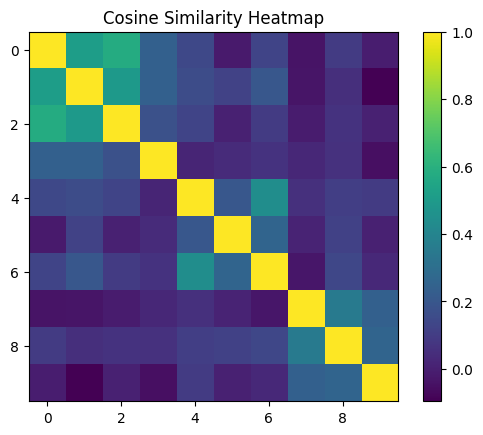

In [15]:
plt.figure()
plt.imshow(similarity_matrix)
plt.colorbar()
plt.title("Cosine Similarity Heatmap")
plt.show()

In [16]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = np.argsort(similarities)[-2:][::-1]

for i in top_indices:
    print("Sentence:", sentences[i])
    print("Similarity Score:", similarities[i])
    print()

Sentence: The bowler took a wicket with a yorker
Similarity Score: 0.748679

Sentence: The team won the cricket match by 5 runs
Similarity Score: 0.5704836

